### 1. Installs

    !pip -q install -U \
      "transformers==4.46.3" \
      "accelerate==0.34.2" \
      "peft==0.13.2" \
      "datasets==2.21.0" \
      "bitsandbytes==0.46.1"

### 2. Merge (old jsonl + new 90k tar), then standardise to instruction/input/output, then make a fixed 80/10/10 train/val/test split from the combined data.

In [6]:
# =========================
# MERGE (old + new) -> standardise -> dedupe -> deterministic 80/10/10 split
# =========================

from pathlib import Path
import json, hashlib

# ---- paths ----
OLD_JSONL = Path(r"C:\Users\sapei\Documents\Case Study\noc-data\noc-stage2-data\stage2.jsonl")
NEW_DIR   = Path(r"C:\Users\sapei\Documents\Case Study\90k-data\90k_dataset\output_descriptions_all")

OUT_DIR = Path(r"C:\Users\sapei\Documents\Case Study\combined_standardised")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- unified prompt strategy ----
INSTRUCTION = (
    "You are given a NoC architecture specification in JSON. "
    "Generate a synthesised network solution. "
    "Return ONLY valid JSON with keys \"switches\" and \"routing_paths\". "
    "No extra text."
)

ARCH_MARK = b"-- Arch Specification: --"
SYN_MARK  = b"-- Synthesised Network: --"

# OLD dataset prompt sections
SPEC_MARK     = b"-- SPEC --"
SWITCHES_MARK = b"-- SWITCHES --"

# -----------------------------
# helpers
# -----------------------------
def canonical(obj) -> str:
    """Deterministic JSON string (stable ordering, no whitespace noise)."""
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), ensure_ascii=False)

def as_canonical_str(x) -> str:
    """If x is already a string, keep it; else canonicalise JSON-serialisable objects."""
    if isinstance(x, str):
        return x
    return canonical(x)

def stable_split(stable_id: str) -> str:
    """
    Deterministic ~80/10/10:
      bucket 0 -> test, bucket 1 -> val, else train.
    """
    b = hashlib.sha1(stable_id.encode("utf-8")).digest()[0] % 10
    if b == 0:
        return "test"
    if b == 1:
        return "val"
    return "train"

def record_hash_id(input_str: str, output_str: str) -> str:
    """Content-based ID: stable across machines/paths/runs."""
    return hashlib.sha1((input_str + "||" + output_str).encode("utf-8")).hexdigest()

def dedupe_key(input_str: str, output_str: str) -> str:
    """Stronger dedupe key; content-based."""
    return hashlib.sha256((input_str + "||" + output_str).encode("utf-8")).hexdigest()

def normalize_target(synth):
    """
    Ensure target is dict with keys: switches, routing_paths.
    Accepts routing/routes as aliases.
    """
    if not isinstance(synth, dict):
        return None

    if "routing_paths" not in synth:
        if "routing" in synth:
            synth["routing_paths"] = synth.pop("routing")
        elif "routes" in synth:
            synth["routing_paths"] = synth.pop("routes")

    if "switches" not in synth or "routing_paths" not in synth:
        return None

    return {"switches": synth["switches"], "routing_paths": synth["routing_paths"]}

def first_json_obj_bytes(b: bytes):
    """Extract first {...} JSON object from bytes (balanced braces)."""
    start = b.find(b"{")
    if start == -1:
        return None
    depth = 0
    for i in range(start, len(b)):
        ch = b[i:i+1]
        if ch == b"{":
            depth += 1
        elif ch == b"}":
            depth -= 1
            if depth == 0:
                return b[start:i+1]
    return None

def make_standard_record(arch_obj, target_obj, source_id: str):
    """Create standardised record with canonical strings + content-based id."""
    input_str  = as_canonical_str(arch_obj)
    output_str = as_canonical_str(target_obj)

    sid = record_hash_id(input_str, output_str)
    return {
        "id": sid,                      
        "source_id": source_id,          
        "instruction": INSTRUCTION,
        "input": input_str,
        "output": output_str,
    }

# -----------------------------
# parsers for NEW dataset files
# -----------------------------
def parse_marker_format(blob: bytes):
    if ARCH_MARK not in blob or SYN_MARK not in blob:
        return None

    after_arch = blob.split(ARCH_MARK, 1)[1]
    arch_part, synth_part = after_arch.split(SYN_MARK, 1)

    arch_b  = first_json_obj_bytes(arch_part.strip())
    synth_b = first_json_obj_bytes(synth_part.strip())
    if arch_b is None or synth_b is None:
        return None

    try:
        arch  = json.loads(arch_b.decode("utf-8", errors="ignore"))
        synth = json.loads(synth_b.decode("utf-8", errors="ignore"))
    except Exception:
        return None

    target = normalize_target(synth)
    if target is None:
        return None
    return arch, target

def parse_json_dict(blob: bytes):
    try:
        obj = json.loads(blob.decode("utf-8", errors="ignore"))
    except Exception:
        return None
    if not isinstance(obj, dict):
        return None

    arch = obj.get("arch") or obj.get("spec") or obj.get("architecture") or obj.get("input")
    synth = obj.get("target") or obj.get("output") or obj.get("solution") or obj.get("synth")

    if isinstance(synth, str):
        try:
            synth = json.loads(synth)
        except Exception:
            synth = None

    if arch is None or synth is None:
        return None

    target = normalize_target(synth)
    if target is None:
        return None
    return arch, target

def parse_two_json_objects(blob: bytes):
    a = first_json_obj_bytes(blob)
    if a is None:
        return None
    rest = blob[blob.find(a) + len(a):]
    s = first_json_obj_bytes(rest)
    if s is None:
        return None

    try:
        arch = json.loads(a.decode("utf-8", errors="ignore"))
        synth = json.loads(s.decode("utf-8", errors="ignore"))
    except Exception:
        return None

    target = normalize_target(synth)
    if target is None:
        return None
    return arch, target

def parse_new_record(blob: bytes):
    return parse_marker_format(blob) or parse_json_dict(blob) or parse_two_json_objects(blob)

# -----------------------------
# parser for OLD stage2.jsonl: prompt + completion
# -----------------------------
def extract_section_json(prompt_str: str, mark: bytes):
    b = prompt_str.encode("utf-8", errors="ignore")
    if mark not in b:
        return None
    after = b.split(mark, 1)[1]
    jb = first_json_obj_bytes(after.strip())
    if jb is None:
        return None
    try:
        return json.loads(jb.decode("utf-8", errors="ignore"))
    except Exception:
        return None

def parse_old_prompt_completion(prompt_str: str, completion_str: str):
    """
    OLD format:
      prompt contains:
        -- SPEC -- {spec json}
        -- SWITCHES -- {switches json}
      completion contains:
        {"routing_paths": ...} (or {"routing":...} / {"routes":...})
    """
    spec = extract_section_json(prompt_str, SPEC_MARK)
    switches = extract_section_json(prompt_str, SWITCHES_MARK)
    if spec is None or switches is None:
        return None

    try:
        comp = json.loads(completion_str)
    except Exception:
        return None

    if isinstance(comp, dict) and "routing_paths" not in comp:
        if "routing" in comp:
            comp["routing_paths"] = comp.pop("routing")
        elif "routes" in comp:
            comp["routing_paths"] = comp.pop("routes")

    if not isinstance(comp, dict) or "routing_paths" not in comp:
        return None

    target = normalize_target({"switches": switches, "routing_paths": comp["routing_paths"]})
    if target is None:
        return None

    return spec, target

# -----------------------------
# sanity checks
# -----------------------------
assert OLD_JSONL.exists(), f"Missing OLD_JSONL: {OLD_JSONL}"
assert NEW_DIR.exists() and NEW_DIR.is_dir(), f"Missing NEW_DIR folder: {NEW_DIR}"

# -----------------------------
# load + merge
# -----------------------------
standardized = []
seen = set()

old_ok = old_fail = 0

with open(OLD_JSONL, "r", encoding="utf-8") as f:
    for idx, line in enumerate(f):
        line = line.strip()
        if not line:
            continue

        try:
            r = json.loads(line)
        except Exception:
            old_fail += 1
            continue

        arch_obj = None
        target_obj = None
        source_id = r.get("id", r.get("uid", f"old_{idx}"))

        # (A) already instruction/input/output
        if all(k in r for k in ["instruction", "input", "output"]):
            # input/output may be str OR dict; canonicalise safely
            arch_obj = r["input"]
            target_obj = r["output"]

        # (B) arch + target style
        elif "arch" in r:
            arch_obj = r["arch"]
            tgt = r.get("target")
            if tgt is None:
                tgt = {
                    "switches": r.get("switches"),
                    "routing_paths": r.get("routing_paths", r.get("routing", r.get("routes"))),
                }
            target_obj = normalize_target(tgt if isinstance(tgt, dict) else {})
            if target_obj is None:
                arch_obj = None

        # (C) prompt + completion style
        elif "prompt" in r and "completion" in r and isinstance(r["prompt"], str) and isinstance(r["completion"], str):
            parsed = parse_old_prompt_completion(r["prompt"], r["completion"])
            if parsed is not None:
                arch_obj, target_obj = parsed

        if arch_obj is None or target_obj is None:
            old_fail += 1
            continue

        rec = make_standard_record(arch_obj, target_obj, source_id=source_id)
        k = dedupe_key(rec["input"], rec["output"])
        if k in seen:
            continue
        seen.add(k)
        standardized.append(rec)
        old_ok += 1

print("OLD kept:", old_ok, "| OLD failed:", old_fail)

new_ok = new_fail = 0

for i, file_path in enumerate(NEW_DIR.rglob("*")):
    if i % 5000 == 0:
        print("Processed:", i, "| new_ok:", new_ok, "| new_fail:", new_fail)

    if not file_path.is_file():
        continue

    blob = file_path.read_bytes()
    parsed = parse_new_record(blob)
    if parsed is None:
        new_fail += 1
        continue

    arch_obj, target_obj = parsed
    rec = make_standard_record(arch_obj, target_obj, source_id=str(file_path))

    k = dedupe_key(rec["input"], rec["output"])
    if k in seen:
        continue
    seen.add(k)
    standardized.append(rec)
    new_ok += 1

print("NEW kept:", new_ok, "| NEW failed:", new_fail)
print("Combined standardised records:", len(standardized))

# -----------------------------
# split + write
# -----------------------------
paths = {
    "train": OUT_DIR / "stage2_train.jsonl",
    "val":   OUT_DIR / "stage2_val.jsonl",
    "test":  OUT_DIR / "stage2_test.jsonl",
    "all":   OUT_DIR / "stage2_all.jsonl",
}

writers = {k: open(v, "w", encoding="utf-8") for k, v in paths.items()}
counts = {k: 0 for k in writers}

# also collect split-wise hashes for leakage checks
split_sets = {"train": set(), "val": set(), "test": set()}

for rec in standardized:
    split = stable_split(rec["id"])  # deterministic from content-based id
    line = json.dumps(rec, ensure_ascii=False)

    writers[split].write(line + "\n")
    counts[split] += 1

    writers["all"].write(line + "\n")
    counts["all"] += 1

    split_sets[split].add(dedupe_key(rec["input"], rec["output"]))

for w in writers.values():
    w.close()

print("Wrote:", {k: str(v) for k, v in paths.items()})
print("Split counts:", counts)

# -----------------------------
# leakage check: no overlap across splits
# -----------------------------
tv = split_sets["train"].intersection(split_sets["val"])
tt = split_sets["train"].intersection(split_sets["test"])
vt = split_sets["val"].intersection(split_sets["test"])

print("Overlap train∩val :", len(tv))
print("Overlap train∩test:", len(tt))
print("Overlap val∩test  :", len(vt))

assert len(tv) == 0 and len(tt) == 0 and len(vt) == 0, "Leakage detected: identical (input,output) in multiple splits!"
print("No leakage across splits (exact duplicates).")

OLD kept: 987 | OLD failed: 0
Processed: 0 | new_ok: 0 | new_fail: 0
Processed: 5000 | new_ok: 5000 | new_fail: 0
Processed: 10000 | new_ok: 10000 | new_fail: 0
Processed: 15000 | new_ok: 15000 | new_fail: 0
Processed: 20000 | new_ok: 20000 | new_fail: 0
Processed: 25000 | new_ok: 25000 | new_fail: 0
Processed: 30000 | new_ok: 30000 | new_fail: 0
Processed: 35000 | new_ok: 35000 | new_fail: 0
Processed: 40000 | new_ok: 40000 | new_fail: 0
Processed: 45000 | new_ok: 45000 | new_fail: 0
Processed: 50000 | new_ok: 50000 | new_fail: 0
Processed: 55000 | new_ok: 55000 | new_fail: 0
Processed: 60000 | new_ok: 60000 | new_fail: 0
Processed: 65000 | new_ok: 65000 | new_fail: 0
Processed: 70000 | new_ok: 70000 | new_fail: 0
Processed: 75000 | new_ok: 75000 | new_fail: 0
Processed: 80000 | new_ok: 80000 | new_fail: 0
Processed: 85000 | new_ok: 85000 | new_fail: 0
NEW kept: 89137 | NEW failed: 0
Combined standardised records: 90124
Wrote: {'train': 'C:\\Users\\sapei\\Documents\\Case Study\\combin

### 3. Stage 2 Routing QLoRA Fine-tuning (with merged 90k) 

In [1]:
# ==================================
# Stage 2 Routing QLoRA Fine-tuning 
# ==================================

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json
import random
from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
from peft import LoraConfig, get_peft_model

# ---------------------------
MODEL_PATH = "openlm-research/open_llama_7b_v2"

TRAIN_JSONL = r"C:\Users\sapei\Documents\Case Study\combined_standardised\stage2_train.jsonl"
VAL_JSONL   = r"C:\Users\sapei\Documents\Case Study\combined_standardised\stage2_val.jsonl"

OUTPUT_DIR = r"C:\Users\sapei\Documents\Case Study\stage2_adapter_90k_budget"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sequence settings
MAX_LENGTH = 512
MIN_OUT_TOKENS = 128

# Data limits
TRAIN_LIMIT = 20000
VAL_LIMIT   = 2000

MAX_STEPS   = 300
EVAL_STEPS  = 50

# Early stopping
PATIENCE_EVALS = 3
MIN_DELTA      = 0.001

# Optim
LR = 1e-4
GRAD_ACCUM = 16
SEED = 42

# Generation sanity check
GEN_LIMIT = 0
MAX_NEW_TOKENS = 256
TEMPERATURE = 0.0
TOP_P = 0.9
PRED_OUT_JSONL = os.path.join(OUTPUT_DIR, "quality_preds.jsonl")


# ---------------------------
# Helpers
# ---------------------------
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_prompt(instruction: str, input_str: str) -> str:
    return (
        "### Instruction:\n"
        f"{instruction}\n\n"
        "### Input:\n"
        f"{input_str}\n\n"
        "### Output:\n"
    )

def tokenize_and_mask(ex: Dict[str, Any]) -> Dict[str, Any]:
    prompt = build_prompt(ex["instruction"], ex["input"])
    target = ex["output"] + tokenizer.eos_token

    prompt_ids = tokenizer(
        prompt,
        truncation=True,
        max_length=MAX_LENGTH - MIN_OUT_TOKENS,
        padding=False,
        add_special_tokens=False,
    )["input_ids"]

    target_ids = tokenizer(
        target,
        truncation=True,
        max_length=MIN_OUT_TOKENS,
        padding=False,
        add_special_tokens=False,
    )["input_ids"]

    input_ids = (prompt_ids + target_ids)[:MAX_LENGTH]
    attention_mask = [1] * len(input_ids)

    labels = ([-100] * len(prompt_ids)) + target_ids
    labels = labels[:MAX_LENGTH]

    pad_len = MAX_LENGTH - len(input_ids)
    if pad_len > 0:
        input_ids += [tokenizer.pad_token_id] * pad_len
        attention_mask += [0] * pad_len
        labels += [-100] * pad_len

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

def count_zero_supervised(ds, n=512) -> Tuple[int, int]:
    n = min(n, len(ds))
    zeros = 0
    for i in range(n):
        labs = np.asarray(ds[i]["labels"])
        if int((labs != -100).sum()) == 0:
            zeros += 1
    return zeros, n

class PlateauStopCallback(TrainerCallback):
    def __init__(self, patience: int, min_delta: float):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best: Optional[float] = None
        self.bad = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics or "eval_loss" not in metrics:
            return control
        cur = float(metrics["eval_loss"])
        if self.best is None or cur < (self.best - self.min_delta):
            self.best = cur
            self.bad = 0
        else:
            self.bad += 1
            if self.bad >= self.patience:
                control.should_training_stop = True
        return control

def extract_first_json_obj(text: str) -> Optional[str]:
    start = text.find("{")
    if start == -1:
        return None
    depth = 0
    for i in range(start, len(text)):
        ch = text[i]
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return text[start:i+1]
    return None

def parse_pred_json(text: str) -> Tuple[bool, Optional[Dict[str, Any]], str]:
    cand = extract_first_json_obj(text.strip())
    if cand is None:
        return False, None, "no_braces"
    try:
        obj = json.loads(cand)
    except Exception:
        return False, None, "json_decode_error"
    if not isinstance(obj, dict):
        return False, None, "not_dict"
    return True, obj, "ok"

def has_required_keys(obj: Dict[str, Any]) -> bool:
    return isinstance(obj, dict) and ("switches" in obj) and ("routing_paths" in obj)

@torch.inference_mode()
def generate_one(ex: Dict[str, Any]) -> str:
    prompt = build_prompt(ex["instruction"], ex["input"])
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    do_sample = TEMPERATURE > 0.0
    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=do_sample,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    if do_sample:
        gen_kwargs["temperature"] = TEMPERATURE
        gen_kwargs["top_p"] = TOP_P

    out = model.generate(**inputs, **gen_kwargs)
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    if "### Output:" in decoded:
        return decoded.split("### Output:", 1)[1].strip()
    return decoded.strip()

@dataclass
class QualityStats:
    n: int
    valid_json: int
    has_keys: int

    @property
    def valid_json_rate(self) -> float:
        return self.valid_json / self.n if self.n else 0.0

    @property
    def has_keys_rate(self) -> float:
        return self.has_keys / self.n if self.n else 0.0

def quality_check(val_raw, gen_limit: int) -> QualityStats:
    gen_limit = min(gen_limit, len(val_raw))
    idxs = list(range(len(val_raw)))
    random.shuffle(idxs)
    idxs = idxs[:gen_limit]

    valid = 0
    keys = 0

    with open(PRED_OUT_JSONL, "w", encoding="utf-8") as f:
        for idx in idxs:
            ex = val_raw[idx]
            pred_text = generate_one(ex)

            ok, obj, reason = parse_pred_json(pred_text)
            if ok:
                valid += 1
                if obj is not None and has_required_keys(obj):
                    keys += 1

            f.write(
                json.dumps(
                    {
                        "id": ex.get("id", str(idx)),
                        "pred_text": pred_text,
                        "parse_ok": ok,
                        "parse_reason": reason,
                        "has_required_keys": bool(obj and has_required_keys(obj)),
                    },
                    ensure_ascii=False,
                ) + "\n"
            )

    return QualityStats(n=gen_limit, valid_json=valid, has_keys=keys)


# ---------------------------
# 0) Seed + device checks
# ---------------------------
set_seed(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA not available. QLoRA 4-bit training will likely not work properly.")


# ---------------------------
# 1) QLoRA config + tokenizer
# ---------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"


# ---------------------------
# 2) Load base model (4-bit)
# ---------------------------
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# ---------------------------
# 3) LoRA adapter config
# ---------------------------
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


# ---------------------------
# 4) Load merged dataset
# ---------------------------
assert os.path.exists(TRAIN_JSONL), f"Missing train file: {TRAIN_JSONL}"
assert os.path.exists(VAL_JSONL), f"Missing val file: {VAL_JSONL}"

dataset = load_dataset(
    "json",
    data_files={"train": TRAIN_JSONL, "validation": VAL_JSONL},
)

train_raw = dataset["train"]
val_raw = dataset["validation"]

if TRAIN_LIMIT and TRAIN_LIMIT > 0:
    train_raw = train_raw.select(range(min(TRAIN_LIMIT, len(train_raw))))
if VAL_LIMIT and VAL_LIMIT > 0:
    val_raw = val_raw.select(range(min(VAL_LIMIT, len(val_raw))))

for split_name, split in [("train", train_raw), ("validation", val_raw)]:
    ex0 = split[0]
    for k in ("instruction", "input", "output"):
        assert k in ex0, f"Missing key '{k}' in {split_name} JSONL."

print(f"Loaded: train={len(train_raw)} val={len(val_raw)}")


# ---------------------------
# 5) Tokenize
# ---------------------------
train_tok = train_raw.map(tokenize_and_mask, remove_columns=train_raw.column_names)
val_tok = val_raw.map(tokenize_and_mask, remove_columns=val_raw.column_names)

z_val, n_val = count_zero_supervised(val_tok, n=512)
assert z_val == 0, f"Val has {z_val}/{n_val} examples with 0 supervised tokens. Increase MIN_OUT_TOKENS."
print(f"Tokenization OK. Train_tok={len(train_tok)} Val_tok={len(val_tok)}")


# ---------------------------
# 6) Training
# ---------------------------
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,

    max_steps=MAX_STEPS,
    num_train_epochs=999,

    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    weight_decay=0.01,

    fp16=True,
    optim="paged_adamw_8bit",

    eval_strategy="steps",
    eval_steps=EVAL_STEPS,

    save_strategy="steps",
    save_steps=EVAL_STEPS,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_steps=10,
    report_to="none",
    remove_unused_columns=False,
    seed=SEED,
    disable_tqdm=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    callbacks=[PlateauStopCallback(patience=PATIENCE_EVALS, min_delta=MIN_DELTA)],
)

train_result = trainer.train()
print("Train result:", train_result)

final_metrics = None


# ---------------------------
# 7) Save adapter + tokenizer
# ---------------------------
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
trainer.state.save_to_json(os.path.join(OUTPUT_DIR, "trainer_state.json"))
print("Saved adapter+tokenizer to:", OUTPUT_DIR)


# ---------------------------
# 8) Export loss history to CSV
# ---------------------------
history = trainer.state.log_history

rows = []
for h in history:
    row = {
        "step": h.get("step"),
        "epoch": h.get("epoch"),
        "loss": h.get("loss"),
        "eval_loss": h.get("eval_loss"),
        "learning_rate": h.get("learning_rate"),
    }
    rows.append(row)

loss_df = pd.DataFrame(rows)
loss_csv = os.path.join(OUTPUT_DIR, "loss_history.csv")
loss_df.to_csv(loss_csv, index=False)
print("Saved loss history CSV to:", loss_csv)


# ---------------------------
# 9) Plot training loss vs steps
# ---------------------------
train_plot_df = loss_df.dropna(subset=["loss", "step"]).copy()
eval_plot_df  = loss_df.dropna(subset=["eval_loss", "step"]).copy()

plt.figure(figsize=(8, 5))
if len(train_plot_df) > 0:
    plt.plot(train_plot_df["step"], train_plot_df["loss"], label="train loss")
if len(eval_plot_df) > 0:
    plt.plot(eval_plot_df["step"], eval_plot_df["eval_loss"], label="eval loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title(f"Training loss vs steps (max_steps={MAX_STEPS})")
plt.grid(True)
plt.legend()
plt.tight_layout()

plot_steps_path = os.path.join(OUTPUT_DIR, "loss_vs_steps.png")
plt.savefig(plot_steps_path, dpi=150)
plt.show()

print("Saved step plot to:", plot_steps_path)


# ---------------------------
# 10) Plot training loss vs epoch
# ---------------------------
train_epoch_df = loss_df.dropna(subset=["loss", "epoch"]).copy()
eval_epoch_df  = loss_df.dropna(subset=["eval_loss", "epoch"]).copy()

plt.figure(figsize=(8, 5))
if len(train_epoch_df) > 0:
    plt.plot(train_epoch_df["epoch"], train_epoch_df["loss"], label="train loss")
if len(eval_epoch_df) > 0:
    plt.plot(eval_epoch_df["epoch"], eval_epoch_df["eval_loss"], label="eval loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss vs epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()

plot_epoch_path = os.path.join(OUTPUT_DIR, "loss_vs_epoch.png")
plt.savefig(plot_epoch_path, dpi=150)
plt.show()

print("Saved epoch plot to:", plot_epoch_path)


# ---------------------------
# 11) Generation quality check
# ---------------------------
print("\nRunning generation quality check...")
q = quality_check(val_raw=val_raw, gen_limit=GEN_LIMIT)

print("\nStage-2 Generation Quality (sampled)")
print("  n:", q.n)
print("  valid_json:", q.valid_json, f"({q.valid_json_rate:.3%})")
print("  has both keys (switches+routing_paths):", q.has_keys, f"({q.has_keys_rate:.3%})")
print("  wrote predictions:", PRED_OUT_JSONL)

print("\nDONE.")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4090 Laptop GPU


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 8,388,608 || all params: 6,746,804,224 || trainable%: 0.1243


Generating train split: 0 examples [00:00, ? examples/s]

...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenization OK. Train_tok=20000 Val_tok=2000


Step,Training Loss,Validation Loss
200,0.185233,0.187355


Train result: TrainOutput(global_step=300, training_loss=0.21426625967025756, metrics={'train_runtime': 4013.8318, 'train_samples_per_second': 1.196, 'train_steps_per_second': 0.075, 'total_flos': 9.75529410822144e+16, 'train_loss': 0.21426625967025756, 'epoch': 0.24})


RuntimeError: on_train_begin must be called before on_evaluate

Clean train logs:


,step,loss
0,20,0.522758
1,40,0.252359
2,60,0.196634
3,80,0.193712
4,100,0.186198
5,120,0.189975
6,140,0.190259
7,160,0.186795
8,180,0.185467
9,200,0.185233


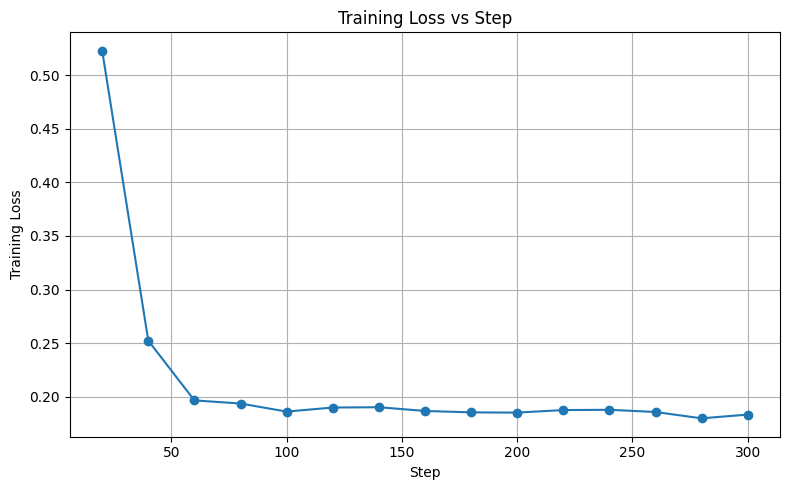

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

history = trainer.state.log_history
df = pd.DataFrame(history)

# Keep only training-loss rows
train_df = df[df["loss"].notna()].copy() if "loss" in df.columns else pd.DataFrame()

# Keep only step and training loss
train_df = train_df[["step", "loss"]].drop_duplicates(subset=["step"], keep="last")

print("Clean train logs:")
display(train_df)

# Save cleaned CSV
train_df.to_csv(os.path.join(OUTPUT_DIR, "train_loss_clean.csv"), index=False)

# Plot training loss vs step
plt.figure(figsize=(8, 5))
if len(train_df) > 0:
    plt.plot(train_df["step"], train_df["loss"], marker="o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Step")
plt.grid(True)
plt.tight_layout()
plt.show()

Clean train logs:


,step,epoch,loss
0,20,0.016,0.522758
1,40,0.032,0.252359
2,60,0.048,0.196634
3,80,0.064,0.193712
4,100,0.080,0.186198
5,120,0.096,0.189975
6,140,0.112,0.190259
7,160,0.128,0.186795
8,180,0.144,0.185467
9,200,0.160,0.185233


Clean eval logs:


,step,epoch,eval_loss
10,200,0.16,0.187355
17,300,0.24,0.187355


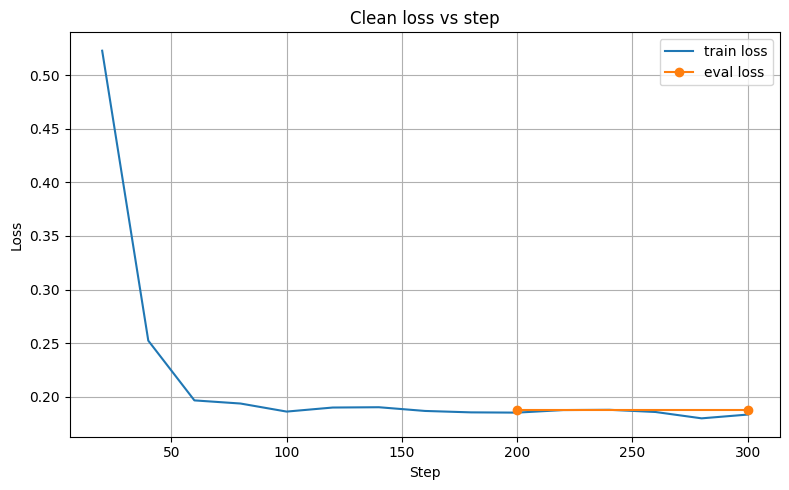

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

history = trainer.state.log_history
df = pd.DataFrame(history)

# Keep only rows that actually contain metric values
train_df = df[df["loss"].notna()].copy() if "loss" in df.columns else pd.DataFrame()
eval_df  = df[df["eval_loss"].notna()].copy() if "eval_loss" in df.columns else pd.DataFrame()

# Keep only the columns we care about
train_df = train_df[["step", "epoch", "loss"]].drop_duplicates(subset=["step"], keep="last")
eval_df  = eval_df[["step", "epoch", "eval_loss"]].drop_duplicates(subset=["step"], keep="last")

print("Clean train logs:")
display(train_df)

print("Clean eval logs:")
display(eval_df)

# Save cleaned CSVs
train_df.to_csv(os.path.join(OUTPUT_DIR, "train_loss_clean.csv"), index=False)
eval_df.to_csv(os.path.join(OUTPUT_DIR, "eval_loss_clean.csv"), index=False)

# Plot loss vs steps
plt.figure(figsize=(8, 5))
if len(train_df) > 0:
    plt.plot(train_df["step"], train_df["loss"], label="train loss")
if len(eval_df) > 0:
    plt.plot(eval_df["step"], eval_df["eval_loss"], marker="o", label="eval loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Clean loss vs step")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()